# Tutorial 4: Filter Duplicate Barcodes

## The Problem

A barcode should appear **once** per trace.
When it appears multiple times, it is a duplicate caused by:

- **Optical artifacts** — Same spot imaged twice (defocus, micro-movement)
- **Detector noise** — Spurious detections registered as separate spots
- **Identical Spot IDs** — Data duplication from processing pipeline

Tutorial 2 QC reveals duplicates in two plots:
- **Trace Statistics** → the N_repeated_barcodes histogram (right panel)
- **Barcode Repetition** → violins above 1.0 = barcodes appearing multiple times

## Available Methods

`trace_filter --clean_spots` handles duplicates in two steps:

1. **Remove duplicate Spot IDs** — identical rows in the trace table
2. **Resolve repeated barcodes** — same barcode appearing multiple times in one trace

For step 2, the behavior depends on whether a localization file is provided:

| Mode | Command | What happens to repeated barcodes |
|------|---------|-----------------------------------|
| **Trace only** | `--clean_spots` | All instances of repeated barcodes are **removed** |
| **With intensity** | `--clean_spots --localization_file Loc.dat` | The spot with the **highest peak intensity** is kept |

## Input

The merged trace file from Tutorial 1: `merged_traces.ecsv`

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148"
dest_path = f"{data_path}/output"

input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input: {input_trace}")

Input: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv


## Method 1: Trace-Only Mode (`--clean_spots`)

Without a localization file, `--clean_spots` takes a conservative approach:
- Duplicate Spot IDs (identical rows) are deduplicated
- For barcodes appearing more than once in a trace, **all instances are removed**

This is conservative: rather than guessing which spot is the "real" one, it removes all of them.
The trade-off is losing some data, but the remaining data is clean.

### Run the filter

In [16]:
!trace_filter --input {input_trace} --clean_spots -O cleaned

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv']
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv

$ Filtering duplicated barcodes

$ Removing duplicated barcodes within traces...
$ Number of rows to remove: 0
$ After filtering, I see 
 spots: 83031 
 traces: 16777

$ Removing spots with repeated barcodes...

$ Number of original 
 spots: 83031 
 traces: 16777
$ Calculating barcode stats...
$ Exporting relative barcode frequencies figure to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_before_filtering.png
$ Number of spots to remove: 5936
$ Removing repeated spots...
$ Number of rows

### Compare before vs after

In [17]:
# Run QC on the cleaned file
cleaned_trace = f"{dest_path}/merged_traces_cleaned.ecsv"
!trace_analyzer --input {cleaned_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned.ecsv
$ Number of spots in trace file: 73796
$ Calculating overall barcode detection across 13431 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.002, Y=0.003, Z=-0.003
$ Calculating barcode stats...
$ Exporting relative barcode frequencies figure to

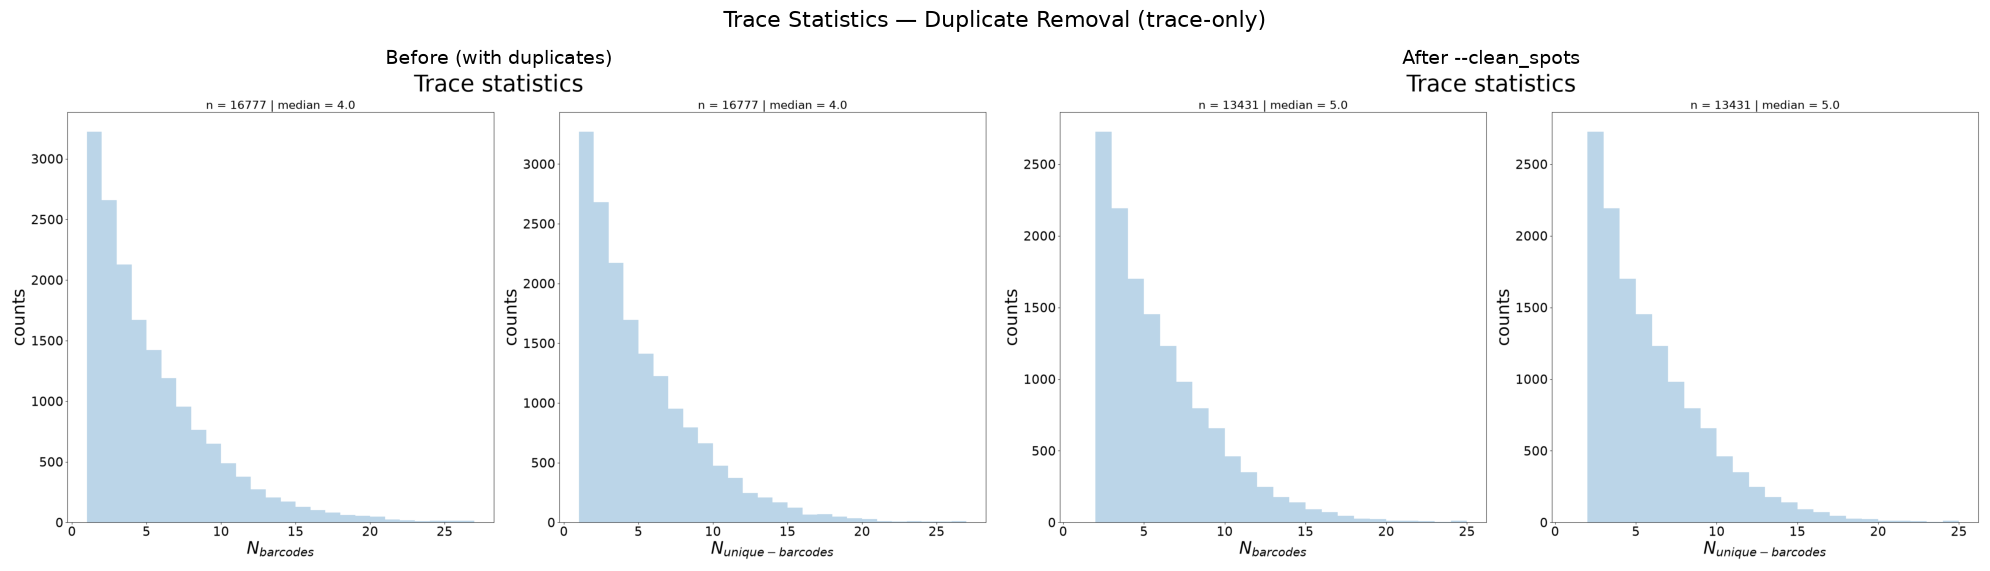

In [20]:
# Before vs after: Trace Statistics
before = f"{dest_path}/merged_traces_trace_statistics.png"
after = f"{dest_path}/merged_traces_cleaned_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before (with duplicates)", "After --clean_spots"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Duplicate Removal (trace-only)", fontsize=16)
plt.tight_layout()
plt.show()

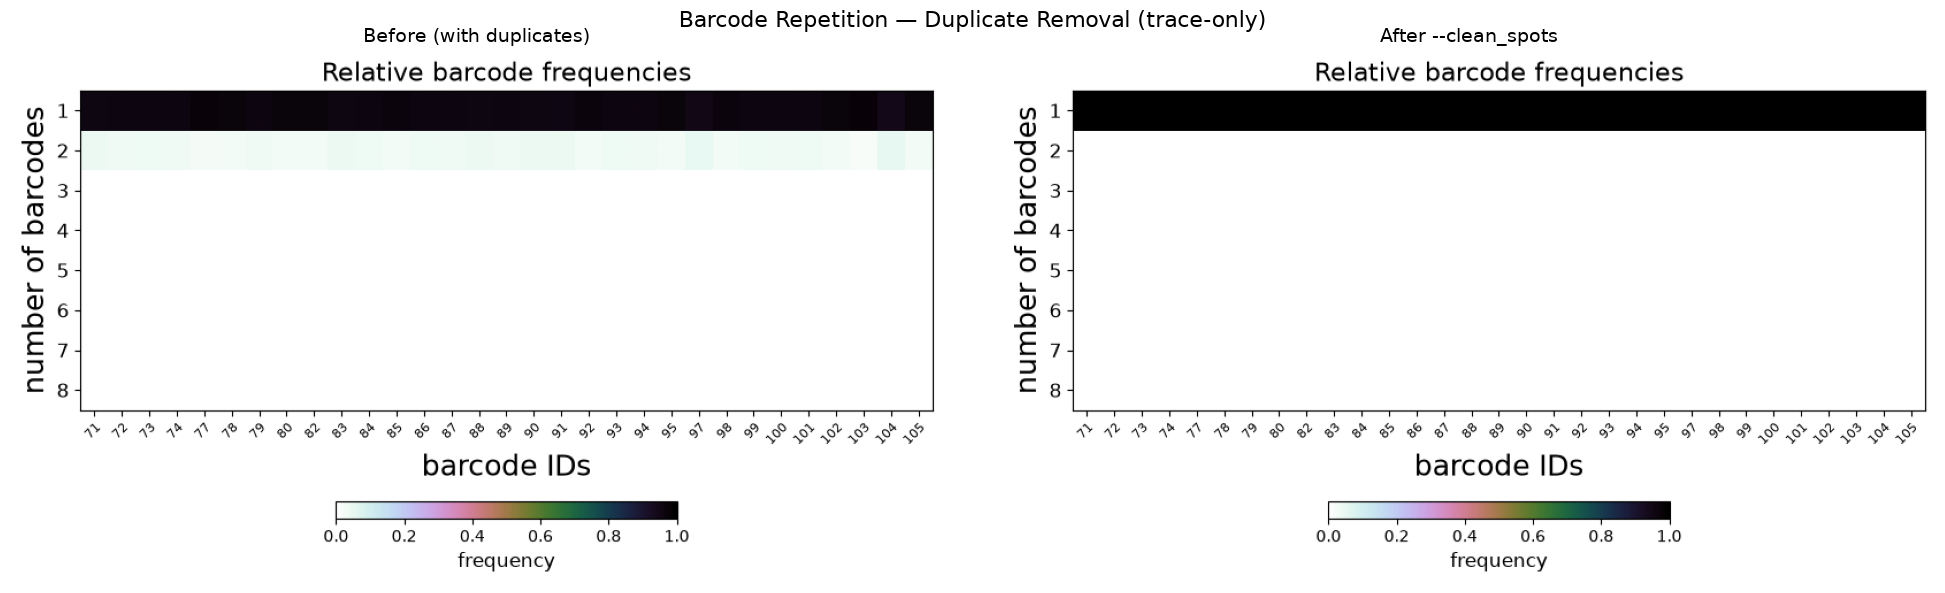

In [21]:
# Before vs after: Barcode Repetition Frequencies
before = f"{dest_path}/merged_traces_relative_barcode_frequencies.png"
after = f"{dest_path}/merged_traces_cleaned_relative_barcode_frequencies.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before (with duplicates)", "After --clean_spots"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Barcode Repetition — Duplicate Removal (trace-only)", fontsize=16)
plt.tight_layout()
plt.show()

**What to check:**
- The N_repeated_barcodes histogram (right panel of Trace Statistics) should drop to near zero
- The Barcode Repetition violins should collapse toward 1.0 (each barcode appears once per trace)

> **Limitation**: In trace-only mode, repeated barcodes are entirely removed (both the real and artifact spots). This means some real detections are lost. Method 2 avoids this by using intensity to choose the best spot.

In [26]:
# Christel's data
data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148"
dest_path = f"{data_path}/output"
input_trace = f"{dest_path}/merged_traces.ecsv"

# Collect localization files from all ROIs
!collect_files \
    --root {data_path}\
    --example-file "localizations_3D_barcode.dat" \
    --copy-to {dest_path}/raw_localizations \
    --rename \
    --force

------- Running collect_files.py --------
Collect one file per subdirectory using pattern matching.

Matched (4):
  ROI_51 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/ROI_51/localizations_3D_barcode.dat
  ROI_52 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/ROI_52/localizations_3D_barcode.dat
  ROI_53 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/ROI_53/localizations_3D_barcode.dat
  ROI_54 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/ROI_54/localizations_3D_barcode.dat
No match (2):
  output
  raw_traces

Decision: nothing copied.
Error: Name collisions in destination:
  localizations_3D_barcode_ROI_51.dat from 'ROI_51' collides with existing file in /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations
  localizations_3D_barcode_ROI_52.dat from 'ROI_52' collides with existing file in /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations
  localizations_3D_barcode_ROI_53.dat from 'ROI_53' collid

## Method 2: Intensity-Based Resolution (`--clean_spots --localization_file`)

When a localization file is available, `trace_filter` can resolve duplicates more intelligently:
for each repeated barcode in a trace, it keeps the spot with the **highest peak intensity** and removes the others.

This preserves more data because the best detection is kept instead of discarding all duplicates.

### Step 1: Collect localization files

Localization files are per-ROI (one per imaging region). We need to collect and merge them,
just like we did for trace files in Tutorial 1.

In [27]:
# Merge all localization files into one ecsv table
!ls {dest_path}/raw_localizations/*.dat | localization_merge -O {dest_path} -o merged_localizations.dat

------- Running localization_merge.py --------
Merge multiple localization files into a single consolidated output.

Input parameters
---------------
outputFolder-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output
output_file-->merged_localizations.dat
loc_files-->['/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations/localizations_3D_barcode_ROI_51.dat', '/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations/localizations_3D_barcode_ROI_52.dat', '/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations/localizations_3D_barcode_ROI_53.dat', '/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations/localizations_3D_barcode_ROI_54.dat']
loc_files4

--------------------------------------------------------------------------------
$ loc file to process: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/raw_localizations/localizations_3D_barcode_ROI_51.dat
$ loc file to process: /m

### Step 2: Run `--clean_spots` with the localization file

By providing `--localization_file`, the duplicate resolution changes:
instead of removing all instances of a repeated barcode, it looks up each spot's **peak intensity**
in the localization table and keeps the brightest one.

In [28]:
loc_file = f"{dest_path}/merged_localizations.dat"

!trace_filter --input {input_trace} --clean_spots --localization_file {loc_file} -O cleaned_intensity

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv']
$ Loaded localizations table with: 107650 rows
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces.ecsv

$ Filtering duplicated barcodes

$ Removing duplicated barcodes within traces...
$ Using intensity to resolve duplicates...
$ Number of rows to remove: 3045
$ After filtering, I see 
 spots: 79986 
 traces: 16777

$ Removing spots with repeated barcodes...

$ Number of original 
 spots: 79986 
 traces: 16777
$ Calculating barcode stats...
$ Exporting relative barcode frequencies figure to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_before_

### Step 3: Compare the two methods

In [29]:
# Run QC on the intensity-cleaned file
intensity_cleaned = f"{dest_path}/merged_traces_cleaned_intensity.ecsv"
!trace_analyzer --input {intensity_cleaned}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_intensity.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_intensity.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_intensity.ecsv
$ Number of spots in trace file: 76716
$ Calculating overall barcode detection across 13507 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_intensity_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Exp148/output/merged_traces_cleaned_intensity_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.004, Y=0.003, Z=-0.001
$ Calculating barcode stats...


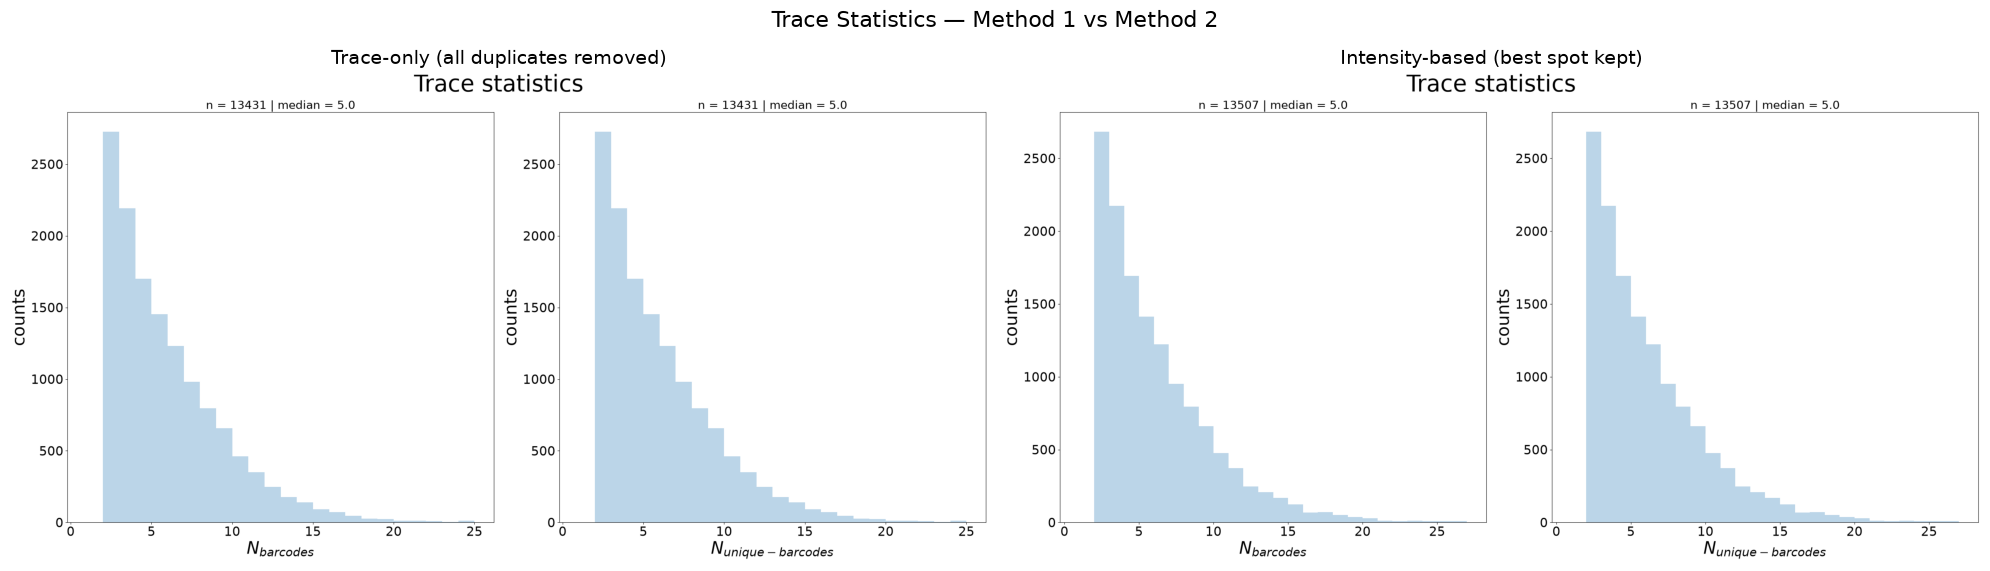

In [30]:
# Compare: trace-only vs intensity-based
trace_only = f"{dest_path}/merged_traces_cleaned_trace_statistics.png"
intensity = f"{dest_path}/merged_traces_cleaned_intensity_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [trace_only, intensity],
                         ["Trace-only (all duplicates removed)",
                          "Intensity-based (best spot kept)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Method 1 vs Method 2", fontsize=16)
plt.tight_layout()
plt.show()

**Expected difference:**
- Method 2 (intensity) preserves more spots because the best duplicate is kept
- The N_barcodes distribution should be shifted right (more barcodes per trace) compared to Method 1
- Both methods should show N_repeated_barcodes near zero

## Quality control of localizations
More user-provided quality thresholds can be found to filter spots with the localization quality control analysis.

**localization_analyzer** loads one localization table and generates a quality-control summary plot for the detected barcode localizations.

In [56]:
data_path="/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC"
localizations = f"{data_path}/localizations_3D_barcode_version_0.dat"
!localization_analyzer --localization_file {localizations}

------- Running localization_analyzer.py --------
Load a localization table and plot localization quality-control distributions.

Input parameters
---------------
localization_file-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0.dat
output_file-->QC
format-->png
Finished execution


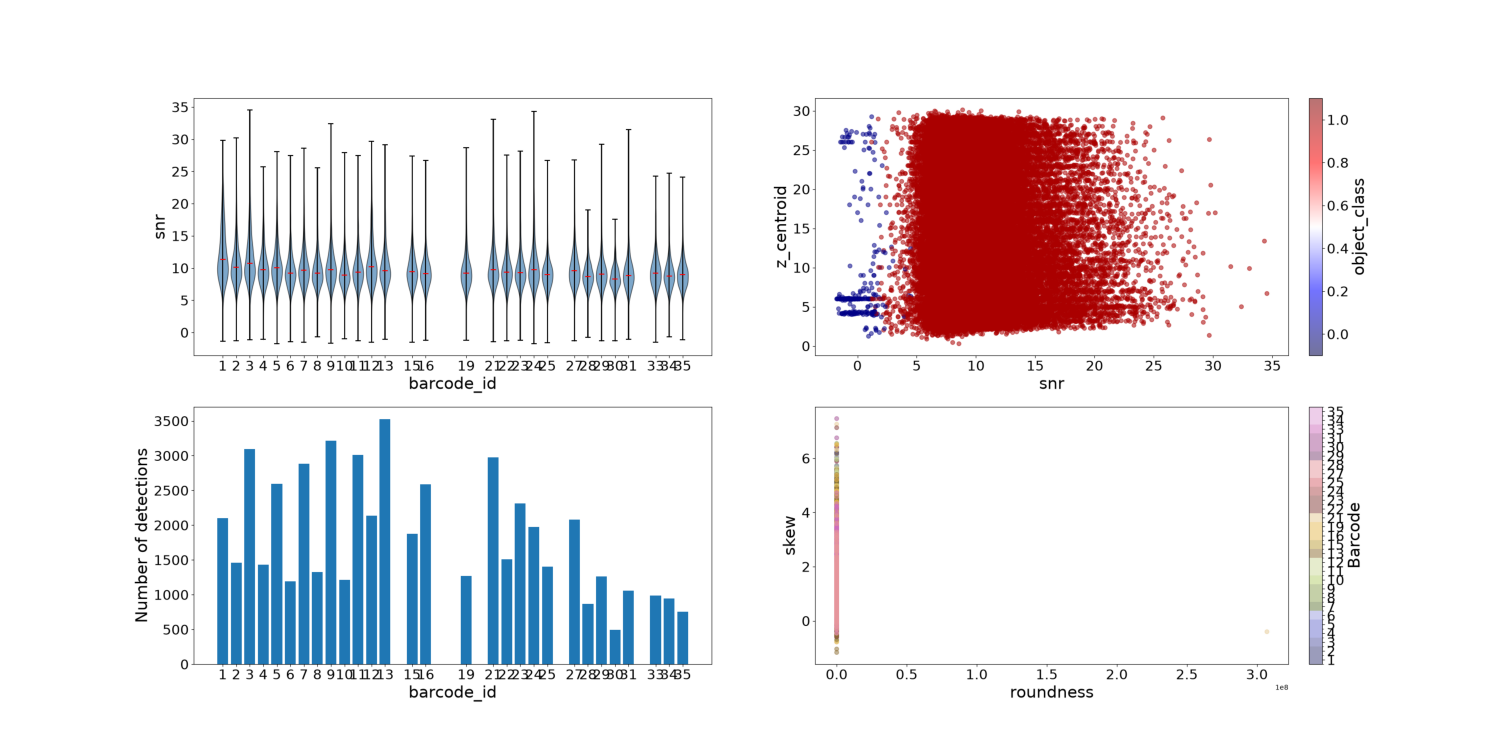

In [65]:
# Display the localization_distribution plots
img = mpimg.imread(f"{data_path}/localization_distribution_fluxes.png")
fig, ax = plt.subplots(figsize=(15, 15))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Filter traces with localization QC

**trace_filter** has more quality filters that can be adjusted with the distribution plots from the quality control analysis.

    From the previous plot, we can choose spots with a low signal to noise ratio (SNR >= 5) and high roudness (=>2), as well as filter the max intensity, and object class to keep spots classified as spots (object_class >= 1) and remove background localizations (object_class == 0).

In [66]:
## comments
localizations = f"{data_path}/localizations_3D_barcode_version_0.dat" 
input_trace = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22.ecsv"
!trace_filter --input {input_trace} --localization_file {localizations} --intensity_min 1000 --skew_min 2 --snr_min 5 --roundness_max 2 --object_class 1 -O filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']
$ Loaded localizations table with: 53519 rows
$ Saved intensity distribution plot as /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0_localization_intensities.png
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Filtering barcodes based on localization quality
> Removed 18621/22866 localizations outside localization quality thresholds (snr>=5.0, skew>=2.0, object_class>=1.0, mean_inte

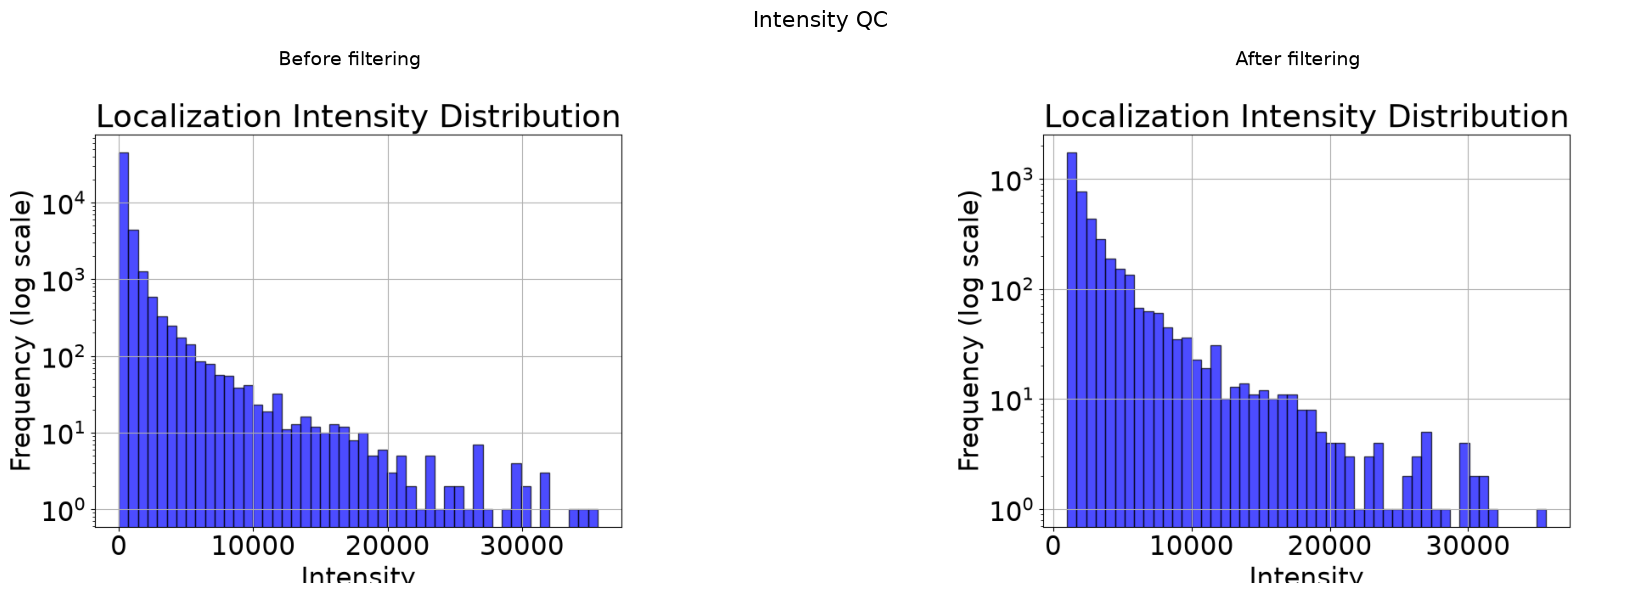

In [67]:
before = f"{data_path}/localizations_3D_barcode_version_0_localization_intensities.png"
after = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_intensities.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before filtering",
                          "After filtering"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Intensity QC ", fontsize=16)
plt.tight_layout()
plt.show()

In [68]:
localizations = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_localizations.ecsv" 
!localization_analyzer --localization_file {localizations}

------- Running localization_analyzer.py --------
Load a localization table and plot localization quality-control distributions.

Input parameters
---------------
localization_file-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22_filtered_localizations.ecsv
output_file-->None
format-->png
Finished execution


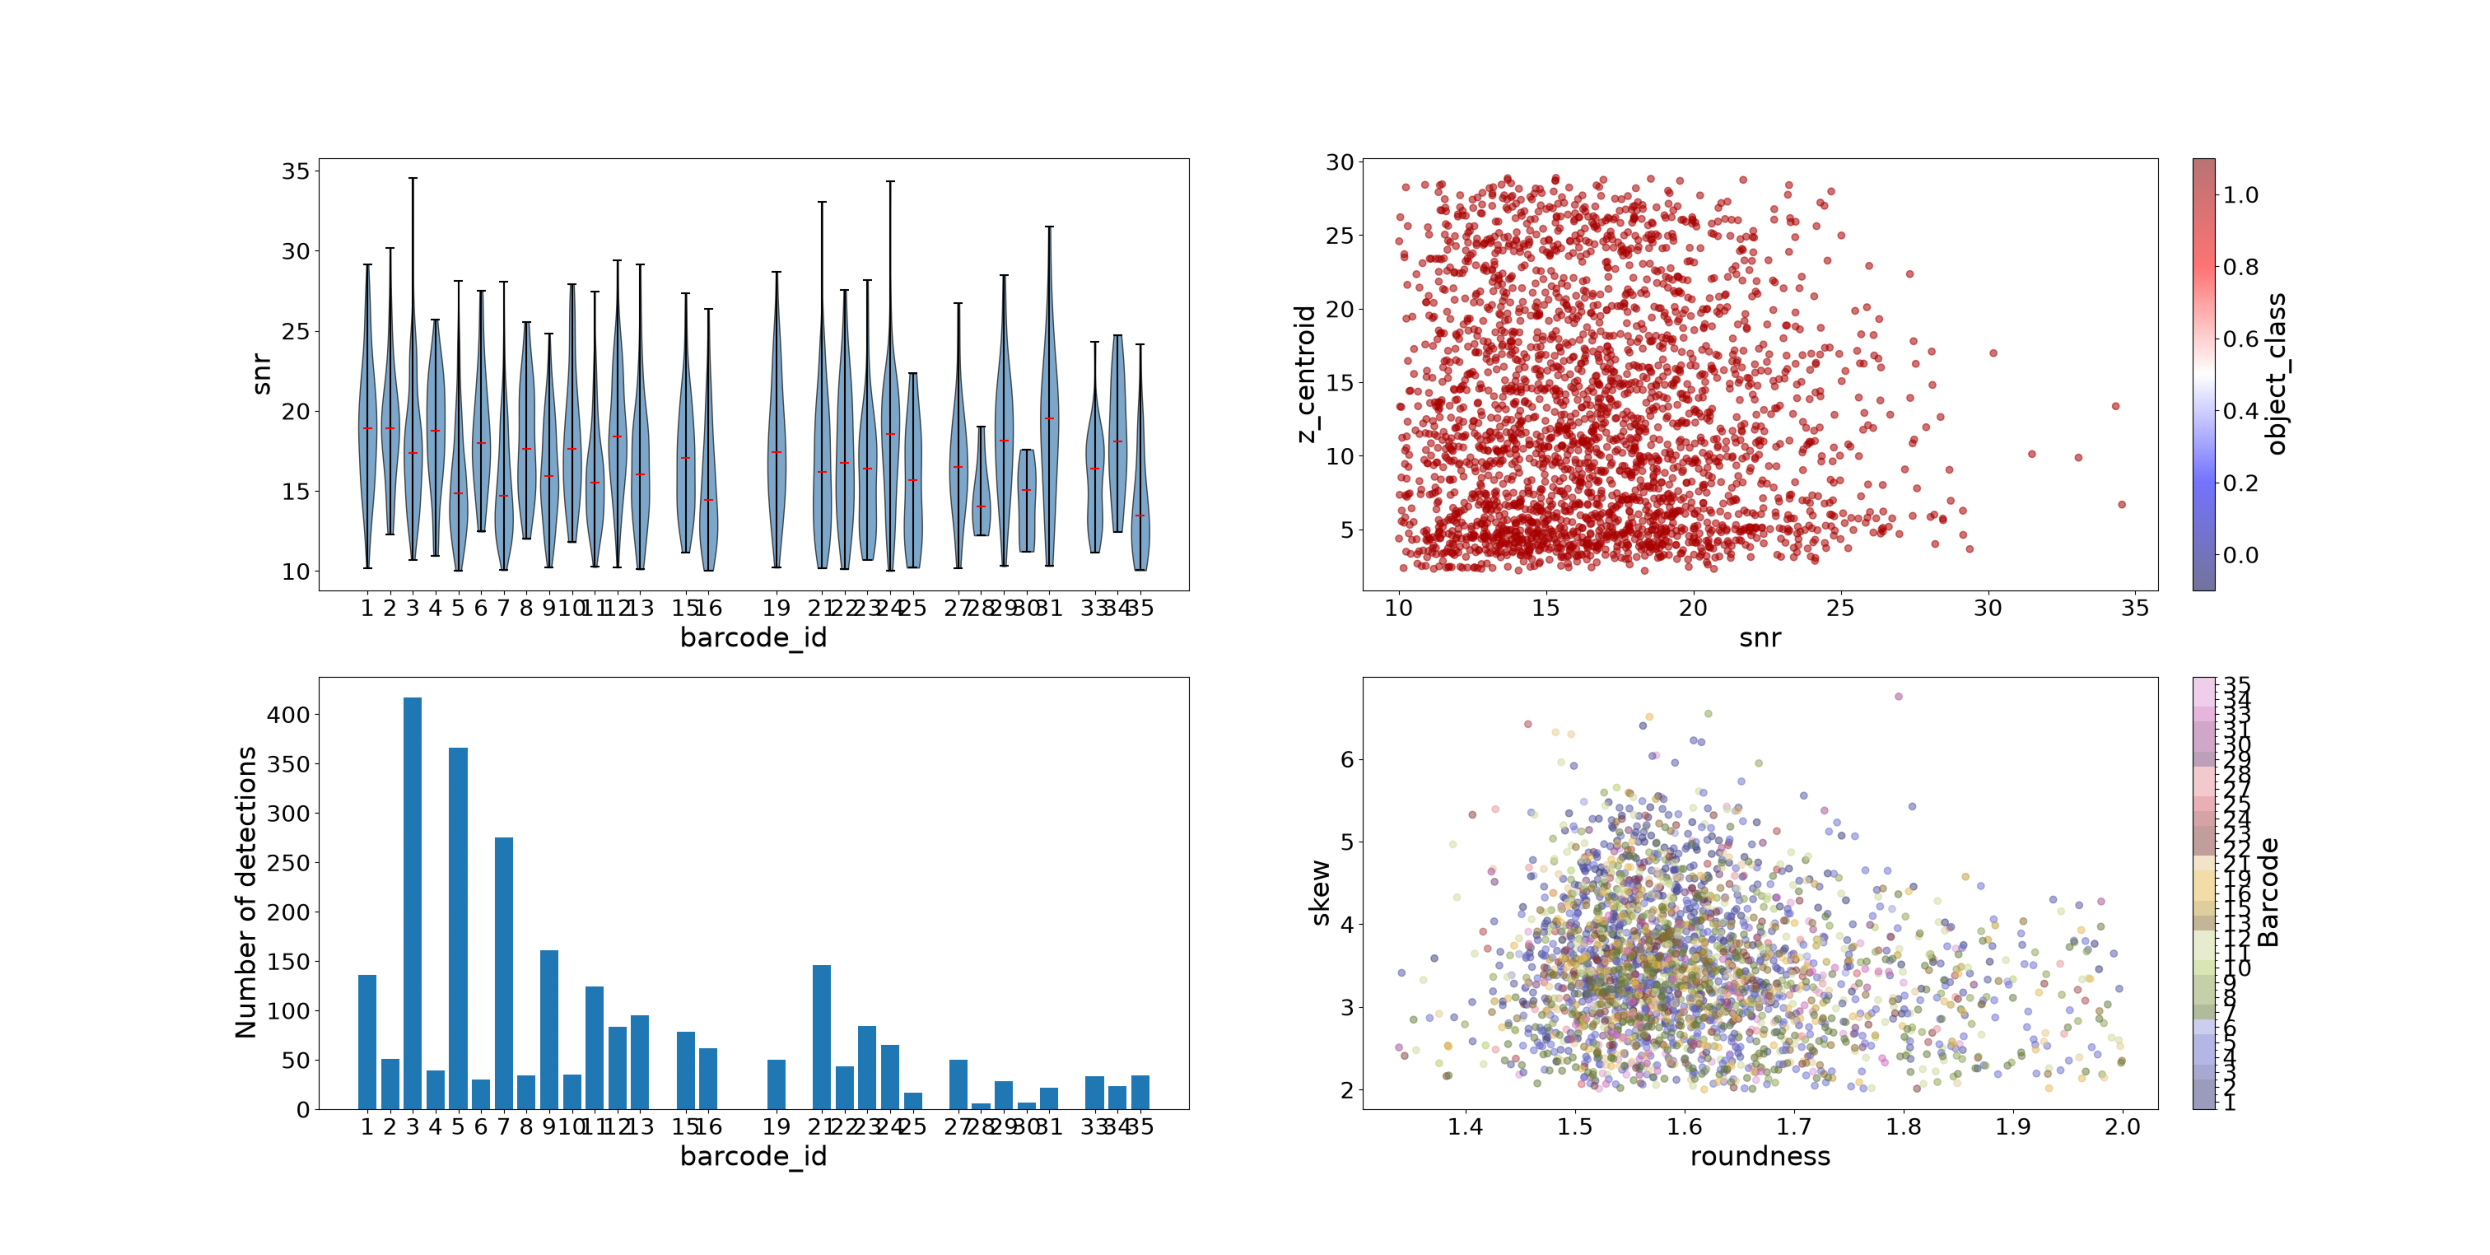

In [73]:
# Compare after filtering
intensity = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_localization_distribution_fluxes.png"
# Display the localization_distribution plots
img = mpimg.imread(intensity)
fig, ax = plt.subplots(figsize=(25, 15))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

Filtering the outliers centers the SNR distribution across barcodes (top left)...


## Combining with Other Filters

Duplicate cleaning is typically combined with other filters in a single command:

```bash
# Trace-only approach
trace_filter --input merged_traces.ecsv \
    --clean_spots \
    --n_barcodes 4 \
    -O final

# With localization intensity
trace_filter --input merged_traces.ecsv \
    --clean_spots \
    --localization_file merged_localizations.dat \
    --n_barcodes 4 \
    -O final
```

**Filter order** inside `trace_filter`:
1. Duplicate/repeated barcode cleaning (`--clean_spots`) ← runs first
2. Coordinate filtering (`--z_min`, etc.)
3. Barcode removal (`--remove_barcode`)
4. Label filtering (`--keep_label` / `--remove_label`)
5. Barcode count (`--n_barcodes`) ← runs last (after other filters reduced trace length)

## Summary

| Method | Command | Behavior | Data preserved |
|--------|---------|----------|----------------|
| Trace-only | `--clean_spots` | Removes all instances of repeated barcodes | Less (conservative) |
| With intensity | `--clean_spots --localization_file` | Keeps highest-peak spot | More (best spot kept) |

**Which to choose?**
- **Trace-only**: Quick, no extra files needed, but removes some real detections
- **With intensity**: Requires localization files but preserves more data. Recommended when localization files are available.

**Next:** [Tutorial 5 — Split Oversized Traces](tutorial_05_split_traces.ipynb)